# FEM vs slide-methode (opnieuw opgebouwd vanaf de opdracht)

Deze notebook vergelijkt opnieuw het FEM-model met de slide-aanpak op basis van een uniforme Euler-Bernoulli balk met:
- ingeklemde voet
- tipmassa `M_tip`
- tip-rotatie-inertie `J_tip`
- top-dashpot `c_dashpot` (alleen in dynamische respons)

Vergelijking op:
- natuurlijke frequenties
- modusvormen
- respons op regelmatige golf
- respons op JONSWAP (zonder en met top-dashpot)

In [15]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
# ----------------------------
# Inputs (zelfde basis als FEM-notebook)
# ----------------------------
h = 35.0
H = 150.0
L = h + H

D = 8.0
t_wall = 0.1

M_tip = 1000e3
J_tip = 1.6e9

E = 210e9
rho_steel = 7850.0

rho_w = 1025.0
g = 9.81
Cm = 2.0

Hs = 6.0
Tp = 12.0
fp = 1.0 / Tp

c_dashpot = 30e3

Ne = 120
n_modes = 3

R_o = D / 2.0
R_i = R_o - t_wall
A = np.pi * (R_o**2 - R_i**2)
I = (np.pi / 4.0) * (R_o**4 - R_i**4)
mu = rho_steel * A
EI = E * I

print(f"A = {A:.6f} m^2, I = {I:.6f} m^4, mu = {mu:.3f} kg/m")

A = 2.481858 m^2, I = 19.364699 m^4, mu = 19482.587 kg/m


In [19]:
# ----------------------------
# FEM basis-model
# ----------------------------
Nn = Ne + 1
Le = L / Ne
ndof = 2 * Nn
z_nodes = np.linspace(-h, H, Nn)

K = np.zeros((ndof, ndof))
M = np.zeros((ndof, ndof))
C = np.zeros((ndof, ndof))

def beam_element_matrices(EI, mu, l):
    ke = (EI / l**3) * np.array([
        [12, 6*l, -12, 6*l],
        [6*l, 4*l**2, -6*l, 2*l**2],
        [-12, -6*l, 12, -6*l],
        [6*l, 2*l**2, -6*l, 4*l**2]
    ])
    me = (mu * l / 420.0) * np.array([
        [156, 22*l, 54, -13*l],
        [22*l, 4*l**2, 13*l, -3*l**2],
        [54, 13*l, 156, -22*l],
        [-13*l, -3*l**2, -22*l, 4*l**2]
    ])
    return ke, me

for e in range(Ne):
    ke, me = beam_element_matrices(EI, mu, Le)
    n1, n2 = e, e + 1
    dofs = np.array([2*n1, 2*n1 + 1, 2*n2, 2*n2 + 1])
    K[np.ix_(dofs, dofs)] += ke
    M[np.ix_(dofs, dofs)] += me

dof_w_top = 2 * (Nn - 1)
dof_th_top = dof_w_top + 1
M[dof_w_top, dof_w_top] += M_tip
M[dof_th_top, dof_th_top] += J_tip
C[dof_w_top, dof_w_top] += c_dashpot

fixed = np.array([0, 1])
free = np.setdiff1d(np.arange(ndof), fixed)
K_ff = K[np.ix_(free, free)]
M_ff = M[np.ix_(free, free)]
C_ff = C[np.ix_(free, free)]

# Eigenoplossing FEM
evals_M, evecs_M = np.linalg.eigh(M_ff)
evals_M = np.maximum(evals_M, 1e-14)
Minvhalf = (evecs_M * (1.0 / np.sqrt(evals_M))) @ evecs_M.T
A_eig = Minvhalf @ K_ff @ Minvhalf
lam, v = np.linalg.eigh(A_eig)
lam = np.maximum(lam, 0.0)
omega_fem = np.sqrt(lam)
freq_fem = omega_fem / (2 * np.pi)
idx = np.argsort(freq_fem)
freq_fem = freq_fem[idx]
omega_fem = omega_fem[idx]
modes_free = (Minvhalf @ v)[:, idx]

modes_fem_w = []
for i in range(n_modes):
    q_full = np.zeros(ndof)
    q_full[free] = modes_free[:, i]
    w_i = q_full[0::2]
    w_i = w_i / np.max(np.abs(w_i))
    modes_fem_w.append(w_i)

for i in range(n_modes):
    print(f"FEM mode {i+1}: f = {freq_fem[i]:.4f} Hz")

FEM mode 1: f = 0.1578 Hz
FEM mode 2: f = 0.8555 Hz
FEM mode 3: f = 2.0982 Hz


In [36]:
# ----------------------------
# FEM validatie: mesh-convergentie eigenfrequenties
# ----------------------------
def fem_modes_for_mesh(Ne_test, n_modes=3):
    Nn_t = Ne_test + 1
    Le_t = L / Ne_test
    ndof_t = 2 * Nn_t

    K_t = np.zeros((ndof_t, ndof_t))
    M_t = np.zeros((ndof_t, ndof_t))

    for e in range(Ne_test):
        ke, me = beam_element_matrices(EI, mu, Le_t)
        n1, n2 = e, e + 1
        dofs = np.array([2*n1, 2*n1 + 1, 2*n2, 2*n2 + 1])
        K_t[np.ix_(dofs, dofs)] += ke
        M_t[np.ix_(dofs, dofs)] += me

    dof_w_top_t = 2 * (Nn_t - 1)
    dof_th_top_t = dof_w_top_t + 1
    M_t[dof_w_top_t, dof_w_top_t] += M_tip
    M_t[dof_th_top_t, dof_th_top_t] += J_tip

    fixed_t = np.array([0, 1])
    free_t = np.setdiff1d(np.arange(ndof_t), fixed_t)
    K_ff_t = K_t[np.ix_(free_t, free_t)]
    M_ff_t = M_t[np.ix_(free_t, free_t)]

    evals_M_t, evecs_M_t = np.linalg.eigh(M_ff_t)
    evals_M_t = np.maximum(evals_M_t, 1e-14)
    Minvhalf_t = (evecs_M_t * (1.0 / np.sqrt(evals_M_t))) @ evecs_M_t.T
    A_t = Minvhalf_t @ K_ff_t @ Minvhalf_t
    lam_t, _ = np.linalg.eigh(A_t)
    lam_t = np.maximum(lam_t, 0.0)
    freq_t = np.sqrt(lam_t) / (2*np.pi)
    return np.sort(freq_t)[:n_modes]

Ne_list = [30, 60, 120, 200, 300]
freq_conv = np.array([fem_modes_for_mesh(Nei, n_modes=3) for Nei in Ne_list])

print('Mesh-convergentie FEM (Hz):')
print('Ne   | f1        f2        f3')
for Nei, fr in zip(Ne_list, freq_conv):
    print(f"{Nei:>4d} | {fr[0]:>8.5f}  {fr[1]:>8.5f}  {fr[2]:>8.5f}")

ref = freq_conv[-1]
err = 100*(freq_conv - ref)/ref
print('\nRelatieve afwijking t.o.v. Ne=300 [%]:')
for Nei, er in zip(Ne_list, err):
    print(f"{Nei:>4d} | {er[0]:>8.3f}  {er[1]:>8.3f}  {er[2]:>8.3f}")

Mesh-convergentie FEM (Hz):
Ne   | f1        f2        f3
  30 |  0.15780   0.85553   2.09816
  60 |  0.15780   0.85553   2.09815
 120 |  0.15780   0.85553   2.09815
 200 |  0.15780   0.85553   2.09815
 300 |  0.15780   0.85553   2.09815

Relatieve afwijking t.o.v. Ne=300 [%]:
  30 |   -0.000     0.000     0.000
  60 |   -0.000     0.000     0.000
 120 |   -0.000     0.000     0.000
 200 |   -0.000     0.000     0.000
 300 |    0.000     0.000     0.000


In [27]:
# ----------------------------
# Slide-methode opnieuw: eigenmodi uit randvoorwaarden met tipmassa + J_tip
# ----------------------------
def _basis(beta, x):
    bx = beta * np.asarray(x)
    c = np.cosh(bx)
    s = np.sinh(bx)
    co = np.cos(bx)
    si = np.sin(bx)

    W = np.vstack((c, s, co, si))
    W1 = beta * np.vstack((s, c, -si, co))
    W2 = beta**2 * np.vstack((c, s, -co, -si))
    W3 = beta**3 * np.vstack((s, c, si, -co))
    return W, W1, W2, W3

def K_slide(omega):
    beta = (omega**2 * mu / EI)**0.25
    W0, W0_1, _, _ = _basis(beta, 0.0)
    WL, WL_1, WL_2, WL_3 = _basis(beta, L)

    Kloc = np.zeros((4, 4), dtype=float)
    Kloc[0, :] = W0[:, 0]
    Kloc[1, :] = W0_1[:, 0]
    Kloc[2, :] = EI * WL_2[:, 0] - J_tip * omega**2 * WL_1[:, 0]
    Kloc[3, :] = EI * WL_3[:, 0] + M_tip * omega**2 * WL[:, 0]
    return Kloc

def sigma_min_slide(omega):
    svals = np.linalg.svd(K_slide(omega), compute_uv=False)
    return float(np.min(svals))

def _bounded_minimize(f, a, b, n_iter=60):
    gr = (np.sqrt(5.0) - 1.0) / 2.0
    c = b - gr * (b - a)
    d = a + gr * (b - a)
    fc = f(c)
    fd = f(d)
    for _ in range(n_iter):
        if fc < fd:
            b, d, fd = d, c, fc
            c = b - gr * (b - a)
            fc = f(c)
        else:
            a, c, fc = c, d, fd
            d = a + gr * (b - a)
            fd = f(d)
    x = 0.5 * (a + b)
    return x, f(x)

def find_slide_modes(n_modes=3, omega_max=25.0, n_grid=30000, sigma_tol=1e-4):
    ws = np.linspace(1e-4, omega_max, n_grid)
    sig = np.array([sigma_min_slide(w) for w in ws])

    candidates = []
    for i in range(1, len(ws) - 1):
        if sig[i] < sig[i - 1] and sig[i] < sig[i + 1]:
            a, b = ws[i - 1], ws[i + 1]
            w_star, s_star = _bounded_minimize(sigma_min_slide, a, b, n_iter=70)
            if s_star < sigma_tol and all(abs(w_star - w0) > 5e-2 for w0, _ in candidates):
                candidates.append((w_star, s_star))

    candidates.sort(key=lambda t: t[0])
    omegas = np.array([w for w, _ in candidates[:n_modes]], dtype=float)
    sigmas = np.array([s for _, s in candidates[:n_modes]], dtype=float)
    return omegas, sigmas, ws, sig

omega_slide, sigma_slide_modes, ws_scan, sig_scan = find_slide_modes(n_modes=n_modes)
if len(omega_slide) < n_modes:
    raise RuntimeError(f"Er zijn slechts {len(omega_slide)} slide-modes gevonden; vergroot omega_max of versoepel sigma_tol.")

freq_slide = omega_slide / (2 * np.pi)

def slide_mode_constants(omega):
    U, S, Vh = np.linalg.svd(K_slide(omega))
    cst = Vh[-1, :]
    return cst / (np.max(np.abs(cst)) + 1e-16)

def mode_shape_slide_x(x, omega):
    beta = (omega**2 * mu / EI)**0.25
    W, _, _, _ = _basis(beta, x)
    cst = slide_mode_constants(omega)
    return np.tensordot(cst, W, axes=(0, 0))

def mode_shape_prime_slide_x(x, omega):
    beta = (omega**2 * mu / EI)**0.25
    _, W1, _, _ = _basis(beta, x)
    cst = slide_mode_constants(omega)
    return np.tensordot(cst, W1, axes=(0, 0))

modes_slide_w = []
for i in range(n_modes):
    x_nodes = z_nodes + h
    w_i = np.real(mode_shape_slide_x(x_nodes, omega_slide[i]))
    w_top = np.real(mode_shape_slide_x(L, omega_slide[i]))
    w_i = w_i / (w_top + 1e-16)
    w_i = w_i / np.max(np.abs(w_i))
    modes_slide_w.append(w_i)

for i in range(n_modes):
    print(f"Slide mode {i+1}: f = {freq_slide[i]:.4f} Hz (sigma_min={sigma_slide_modes[i]:.2e})")

Slide mode 1: f = 0.1578 Hz (sigma_min=9.19e-11)
Slide mode 2: f = 0.8555 Hz (sigma_min=1.18e-10)
Slide mode 3: f = 2.0982 Hz (sigma_min=2.37e-07)


Mode | f_FEM [Hz] | f_slide [Hz] | rel. diff [%]
   1 |     0.1578 |      0.1578 |        0.00
   2 |     0.8555 |      0.8555 |        0.00
   3 |     2.0982 |      2.0982 |        0.00


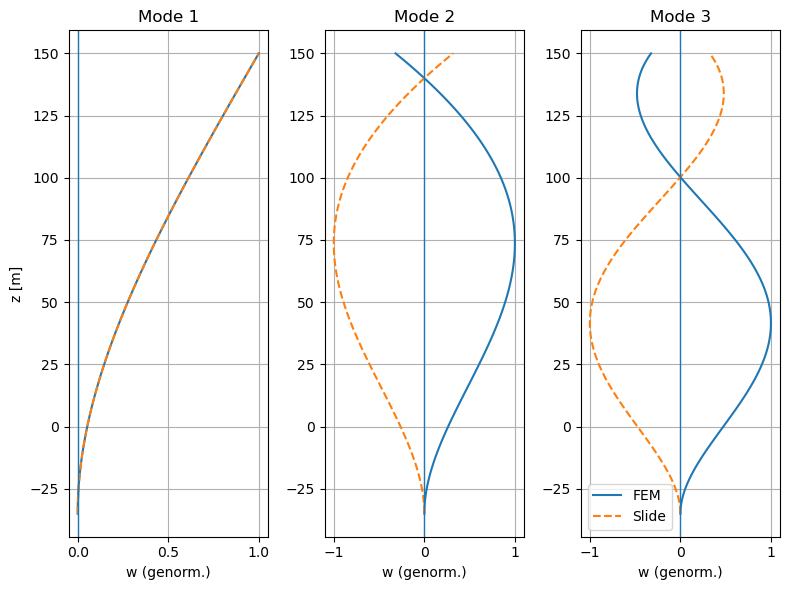

In [28]:
# ----------------------------
# Vergelijking vrije trillingen
# ----------------------------
print('Mode | f_FEM [Hz] | f_slide [Hz] | rel. diff [%]')
for i in range(n_modes):
    rel = 100.0 * (freq_slide[i] - freq_fem[i]) / freq_fem[i]
    print(f"{i+1:>4d} | {freq_fem[i]:>10.4f} | {freq_slide[i]:>11.4f} | {rel:>11.2f}")

plt.figure(figsize=(8, 6))
for i in range(n_modes):
    plt.subplot(1, 3, i+1)
    plt.plot(modes_fem_w[i], z_nodes, label='FEM')
    plt.plot(modes_slide_w[i], z_nodes, '--', label='Slide')
    plt.axvline(0, linewidth=1)
    plt.title(f'Mode {i+1}')
    plt.xlabel('w (genorm.)')
    if i == 0:
        plt.ylabel('z [m]')
    plt.grid(True)
    if i == 2:
        plt.legend()
plt.tight_layout()
plt.show()

In [29]:
# ----------------------------
# Helpers voor golfbelasting
# ----------------------------
def solve_dispersion(omega, h, g=9.81):
    k = omega**2 / g
    for _ in range(60):
        f = g*k*np.tanh(k*h) - omega**2
        df = g*np.tanh(k*h) + g*k*h*(1/np.cosh(k*h))**2
        k_new = k - f/df
        if abs(k_new - k) < 1e-12:
            break
        k = k_new
    return k

A_disp = np.pi * D**2 / 4.0
i_swl = int(np.argmin(np.abs(z_nodes - 0.0)))
i_top = Nn - 1

def regular_wave_line_load_amp(z, omega, a):
    k = solve_dispersion(omega, h, g)
    u_ddot = a * omega**2 * np.cosh(k*(z + h)) / np.sinh(k*h)
    return rho_w * Cm * A_disp * u_ddot

def fem_regular_response(Tp, with_dashpot=False):
    omega = 2*np.pi/Tp
    a = Hs / 2.0

    Fhat = np.zeros(ndof, dtype=complex)
    for e in range(Ne):
        zmid = 0.5 * (z_nodes[e] + z_nodes[e+1])
        if zmid > 0.0:
            continue
        p = regular_wave_line_load_amp(zmid, omega, a)
        fe = (p * Le / 12.0) * np.array([6.0, Le, 6.0, -Le])
        n1, n2 = e, e+1
        dofs = np.array([2*n1, 2*n1+1, 2*n2, 2*n2+1])
        Fhat[dofs] += fe

    Dyn = K_ff - omega**2 * M_ff
    if with_dashpot:
        Dyn = Dyn + 1j*omega*C_ff
    Dyn = Dyn + 1e-10*np.max(np.abs(K_ff))*np.eye(Dyn.shape[0])

    qhat_free = np.linalg.solve(Dyn, Fhat[free])
    qhat = np.zeros(ndof, dtype=complex)
    qhat[free] = qhat_free
    w_hat_nodes = qhat[0::2]
    return omega, w_hat_nodes[i_swl], w_hat_nodes[i_top]

def jonswap(f, Hs, Tp, gamma=3.3):
    fp = 1.0 / Tp
    alpha = 0.0624 / (0.230 + 0.0336*gamma - 0.185*(1.9 + gamma)**-1)
    sigma = np.where(f <= fp, 0.07, 0.09)
    r = np.exp(-0.5 * ((f - fp) / (sigma * fp))**2)
    S = (alpha * Hs**2 * fp**4 * f**-5
         * np.exp(-1.25 * (fp / f)**4)
         * gamma**r)
    return S

In [33]:
# ----------------------------
# Slide-methode dynamische respons via modale superpositie (opnieuw afgeleid)
# ----------------------------
z_int = np.linspace(-h, H, 3000)
z_wet = np.linspace(-h, 0.0, 1200)
x_int = z_int + h
x_wet = z_wet + h

phi_r = []
phi_r_prime_top = []
m_r = []
k_r = []
c_r = []

for r in range(n_modes):
    omega_r = omega_slide[r]
    phi_vals = np.real(mode_shape_slide_x(x_int, omega_r))
    phi_top_r = float(np.real(mode_shape_slide_x(L, omega_r)).item())
    phi_vals = phi_vals / (phi_top_r + 1e-16)

    phi_prime_top = float(np.real(mode_shape_prime_slide_x(L, omega_r)).item() / (phi_top_r + 1e-16))

    m_gen = float(np.trapezoid(mu * phi_vals**2, z_int) + M_tip + J_tip * phi_prime_top**2)
    k_gen = float(m_gen * omega_r**2)
    c_gen = float(c_dashpot)

    phi_r.append(phi_vals)
    phi_r_prime_top.append(phi_prime_top)
    m_r.append(m_gen)
    k_r.append(k_gen)
    c_r.append(c_gen)

phi_r = np.array(phi_r)
phi_r_prime_top = np.array(phi_r_prime_top)
m_r = np.array(m_r)
k_r = np.array(k_r)
c_r = np.array(c_r)

phi_swl = np.array([
    float(np.real(mode_shape_slide_x(h, omega_slide[r])).item() / (np.real(mode_shape_slide_x(L, omega_slide[r])).item() + 1e-16))
    for r in range(n_modes)
])
phi_top = np.ones(n_modes)

def slide_harmonic_response(Tp, with_dashpot=False):
    omega = 2*np.pi/Tp
    a = Hs / 2.0
    p = regular_wave_line_load_amp(z_wet, omega, a)

    q_hat = np.zeros(n_modes, dtype=complex)
    for r in range(n_modes):
        phi_top_r = float(np.real(mode_shape_slide_x(L, omega_slide[r])).item())
        phi_wet = np.real(mode_shape_slide_x(x_wet, omega_slide[r])) / (phi_top_r + 1e-16)
        Q_hat = np.trapezoid(p * phi_wet, z_wet)
        den = k_r[r] - omega**2*m_r[r]
        if with_dashpot:
            den = den + 1j*omega*c_r[r]
        den = den + 1e-12
        q_hat[r] = Q_hat / den

    w_hat_swl = np.sum(phi_swl * q_hat)
    w_hat_top = np.sum(phi_top * q_hat)
    return omega, w_hat_swl, w_hat_top

FEM   |w_hat(SWL)| = 4.514050e-03 m, |w_hat(Top)| = 3.579152e-02 m
Slide |w_hat(SWL)| = 3.391082e-03 m, |w_hat(Top)| = 3.607392e-02 m


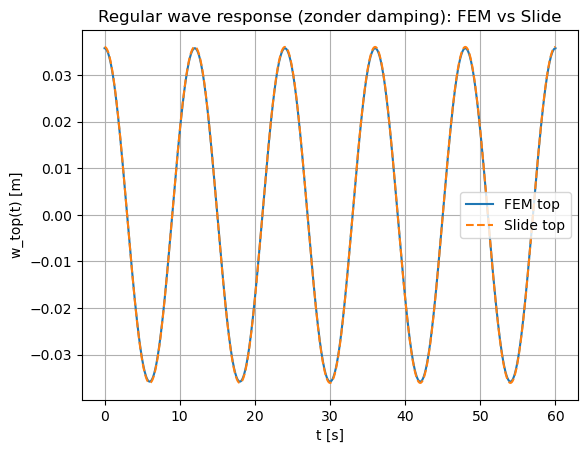

In [34]:
# ----------------------------
# Vergelijking: regular wave (zonder damping)
# ----------------------------
omega_f, w_swl_f, w_top_f = fem_regular_response(Tp, with_dashpot=False)
omega_s, w_swl_s, w_top_s = slide_harmonic_response(Tp, with_dashpot=False)

print(f'FEM   |w_hat(SWL)| = {abs(w_swl_f):.6e} m, |w_hat(Top)| = {abs(w_top_f):.6e} m')
print(f'Slide |w_hat(SWL)| = {abs(w_swl_s):.6e} m, |w_hat(Top)| = {abs(w_top_s):.6e} m')

t_reg = np.linspace(0, 5*Tp, 2000)
w_top_f_t = np.real(w_top_f * np.exp(1j*omega_f*t_reg))
w_top_s_t = np.real(w_top_s * np.exp(1j*omega_s*t_reg))

plt.figure()
plt.plot(t_reg, w_top_f_t, label='FEM top')
plt.plot(t_reg, w_top_s_t, '--', label='Slide top')
plt.xlabel('t [s]')
plt.ylabel('w_top(t) [m]')
plt.title('Regular wave response (zonder damping): FEM vs Slide')
plt.grid(True)
plt.legend()
plt.show()

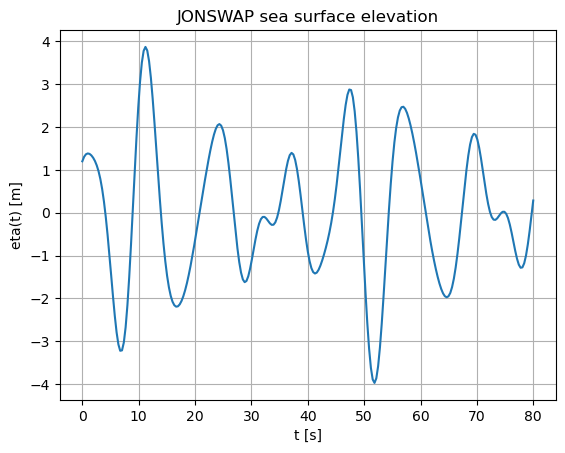

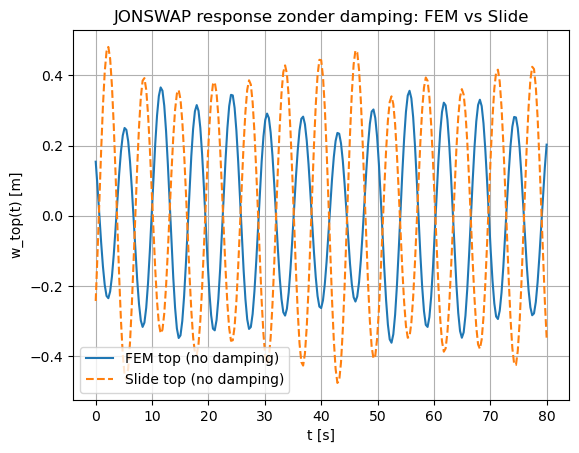

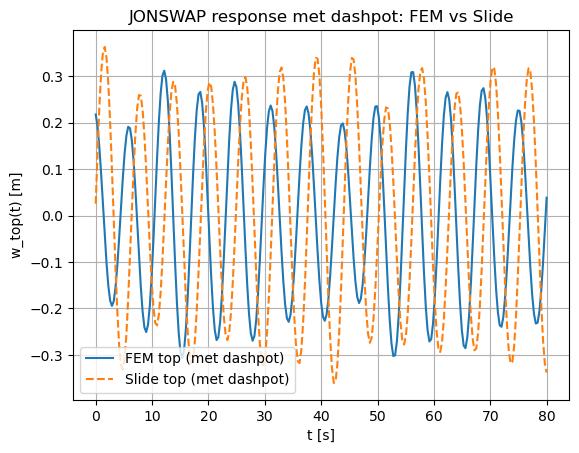

In [35]:
# ----------------------------
# Vergelijking: JONSWAP zonder en met dashpot
# ----------------------------
N = 6
freqs_samp = np.linspace(0.75*fp, 2.2*fp, N)
omegas = 2*np.pi*freqs_samp
df = freqs_samp[1] - freqs_samp[0]
S_samp = jonswap(freqs_samp, Hs, Tp)
amps_eta = np.sqrt(2*S_samp*df)

np.random.seed(42)
phases = np.random.uniform(0, 2*np.pi, N)

T_max = 1.0 / freqs_samp[0]
t_end = 5*T_max
dt = T_max / 50
t = np.arange(0, t_end + dt, dt)

eta = np.zeros_like(t)
for amp, omega_i, phi_i in zip(amps_eta, omegas, phases):
    eta += amp*np.cos(omega_i*t + phi_i)

w_top_fem = np.zeros_like(t)
w_top_slide = np.zeros_like(t)
w_top_fem_d = np.zeros_like(t)
w_top_slide_d = np.zeros_like(t)

for omega_i, eta_i, phase_i in zip(omegas, amps_eta, phases):
    Tp_i = 2*np.pi/omega_i

    # FEM component
    a_i = eta_i
    Fhat = np.zeros(ndof, dtype=complex)
    k_i = solve_dispersion(omega_i, h, g)
    for e in range(Ne):
        zmid = 0.5*(z_nodes[e] + z_nodes[e+1])
        if zmid > 0.0:
            continue
        u_ddot = a_i * omega_i**2 * np.cosh(k_i*(zmid + h)) / np.sinh(k_i*h)
        p_i = rho_w * Cm * A_disp * u_ddot
        fe = (p_i * Le / 12.0) * np.array([6.0, Le, 6.0, -Le]) * np.exp(1j*phase_i)
        n1, n2 = e, e+1
        dofs = np.array([2*n1, 2*n1+1, 2*n2, 2*n2+1])
        Fhat[dofs] += fe

    Dyn = K_ff - omega_i**2*M_ff + 1e-10*np.max(np.abs(K_ff))*np.eye(K_ff.shape[0])
    Dyn_d = K_ff + 1j*omega_i*C_ff - omega_i**2*M_ff + 1e-10*np.max(np.abs(K_ff))*np.eye(K_ff.shape[0])

    qf = np.linalg.solve(Dyn, Fhat[free])
    qf_d = np.linalg.solve(Dyn_d, Fhat[free])

    q_full = np.zeros(ndof, dtype=complex)
    q_full_d = np.zeros(ndof, dtype=complex)
    q_full[free] = qf
    q_full_d[free] = qf_d
    w_top_hat_f = q_full[0::2][i_top]
    w_top_hat_f_d = q_full_d[0::2][i_top]

    # Slide component
    p_wet = a_i * omega_i**2 * np.cosh(k_i*(z_wet + h)) / np.sinh(k_i*h)
    p_wet = rho_w * Cm * A_disp * p_wet

    w_top_hat_s = 0.0 + 0.0j
    w_top_hat_s_d = 0.0 + 0.0j
    for r in range(n_modes):
        phi_wet = mode_shape_slide(z_wet, beta[r], L, h) / mode_shape_slide(H, beta[r], L, h)
        Q_hat = np.trapezoid(p_wet * phi_wet, z_wet) * np.exp(1j*phase_i)

        den = (k_r[r] - omega_i**2*m_r[r]) + 1e-12
        den_d = (k_r[r] - omega_i**2*m_r[r]) + 1j*omega_i*c_r[r] + 1e-12

        q_hat = Q_hat / den
        q_hat_d = Q_hat / den_d

        w_top_hat_s += q_hat
        w_top_hat_s_d += q_hat_d

    w_top_fem += np.real(w_top_hat_f * np.exp(1j*omega_i*t))
    w_top_slide += np.real(w_top_hat_s * np.exp(1j*omega_i*t))
    w_top_fem_d += np.real(w_top_hat_f_d * np.exp(1j*omega_i*t))
    w_top_slide_d += np.real(w_top_hat_s_d * np.exp(1j*omega_i*t))

plt.figure()
plt.plot(t, eta)
plt.xlabel('t [s]')
plt.ylabel('eta(t) [m]')
plt.title('JONSWAP sea surface elevation')
plt.grid(True)
plt.show()

plt.figure()
plt.plot(t, w_top_fem, label='FEM top (no damping)')
plt.plot(t, w_top_slide, '--', label='Slide top (no damping)')
plt.xlabel('t [s]')
plt.ylabel('w_top(t) [m]')
plt.title('JONSWAP response zonder damping: FEM vs Slide')
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(t, w_top_fem_d, label='FEM top (met dashpot)')
plt.plot(t, w_top_slide_d, '--', label='Slide top (met dashpot)')
plt.xlabel('t [s]')
plt.ylabel('w_top(t) [m]')
plt.title('JONSWAP response met dashpot: FEM vs Slide')
plt.grid(True)
plt.legend()
plt.show()